# RetailPulse AI – Day 4: Time Series Preparation & Sales Trend Analysis

### Prepared By: Bansi Kanani

### Date: 01 June 2026

# Introduction

Time-series analysis helps businesses understand sales trends, seasonality, and purchasing patterns over time.

This notebook prepares retail sales data for forecasting models such as Prophet and LSTM.

# Objective

The objectives of Day 4 are:

- Prepare time-series data
- Analyze sales trends
- Visualize rolling statistics
- Perform stationarity testing
- Decompose trend and seasonality
- Prepare forecasting-ready data

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
df = pd.read_csv(
    "cleaned_online_retail.csv"
)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1


In [3]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

# Daily Sales Aggregation

Sales are aggregated at the daily level to create a time-series dataset.

In [4]:
daily_sales = (
    df.groupby(
        df["InvoiceDate"].dt.date
    )["Revenue"]
    .sum()
    .reset_index()
)

daily_sales.columns = [
    "Date",
    "Sales"
]

daily_sales.head()

,Date,Sales
0,2009-12-01,43894.87
1,2009-12-02,52762.06
2,2009-12-03,67413.62
3,2009-12-04,33913.81
4,2009-12-05,9803.05


In [5]:
print(
    "Total Daily Records:",
    len(daily_sales)
)

Total Daily Records: 604


# Sales Trend Visualization

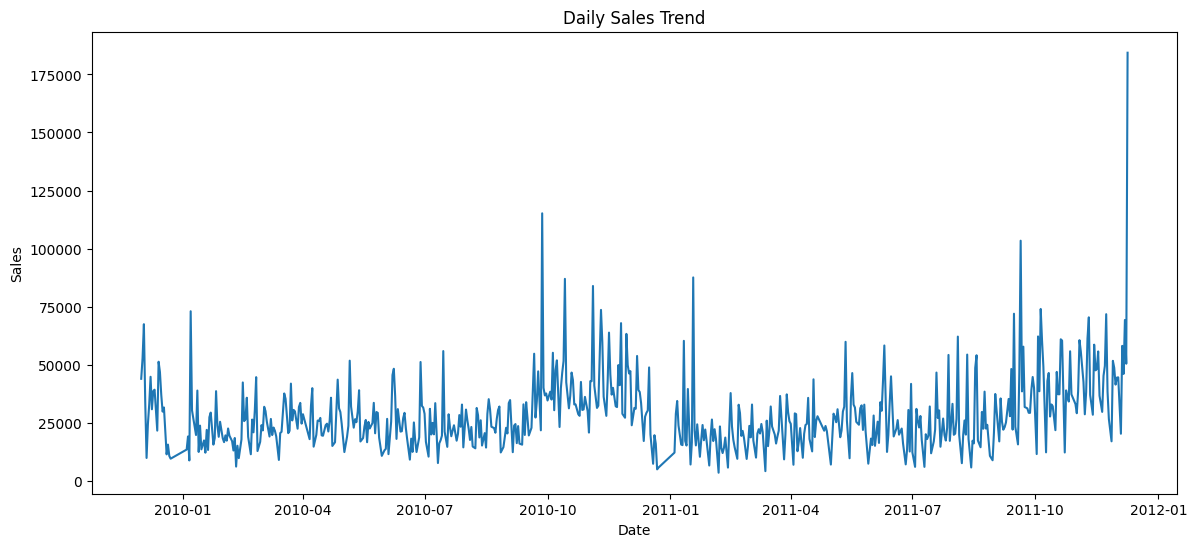

In [6]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_sales["Date"],
    daily_sales["Sales"]
)

plt.title(
    "Daily Sales Trend"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

# Rolling Statistics

Rolling statistics help smooth short-term fluctuations and reveal underlying sales trends.

In [7]:
daily_sales["Rolling_Mean"] = (
    daily_sales["Sales"]
    .rolling(window=30)
    .mean()
)

daily_sales["Rolling_STD"] = (
    daily_sales["Sales"]
    .rolling(window=30)
    .std()
)

daily_sales.head()

,Date,Sales,Rolling_Mean,Rolling_STD
0,2009-12-01,43894.87,NaN,NaN
1,2009-12-02,52762.06,NaN,NaN
2,2009-12-03,67413.62,NaN,NaN
3,2009-12-04,33913.81,NaN,NaN
4,2009-12-05,9803.05,NaN,NaN


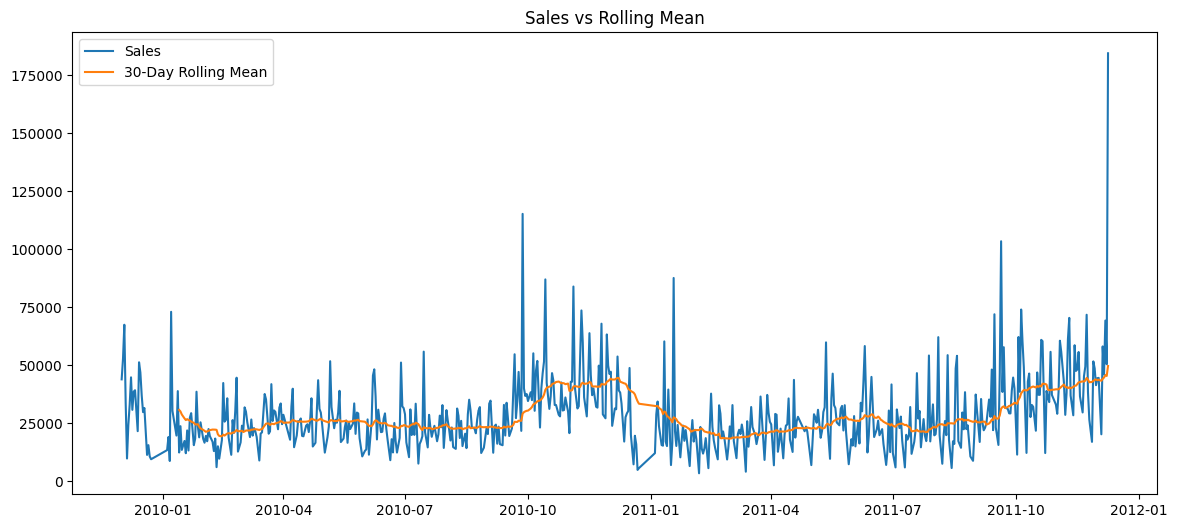

In [8]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_sales["Date"],
    daily_sales["Sales"],
    label="Sales"
)

plt.plot(
    daily_sales["Date"],
    daily_sales["Rolling_Mean"],
    label="30-Day Rolling Mean"
)

plt.legend()

plt.title(
    "Sales vs Rolling Mean"
)

plt.show()

# Stationarity Test

The Augmented Dickey-Fuller (ADF) test is used to determine whether the time series is stationary.

In [9]:
result = adfuller(
    daily_sales["Sales"]
)

print(
    "ADF Statistic:",
    result[0]
)

print(
    "p-value:",
    result[1]
)

ADF Statistic: -1.6512185752853836
p-value: 0.4564049792435114


# Seasonal Decomposition

Seasonal decomposition separates the series into:

- Trend
- Seasonality
- Residual Components

In [10]:
daily_sales_ts = daily_sales.copy()

daily_sales_ts["Date"] = pd.to_datetime(
    daily_sales_ts["Date"]
)

daily_sales_ts = (
    daily_sales_ts
    .set_index("Date")
)

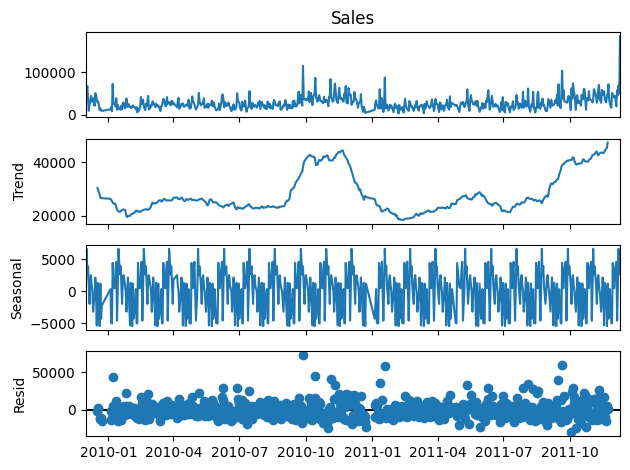

In [11]:
decomposition = seasonal_decompose(
    daily_sales_ts["Sales"],
    model="additive",
    period=30
)

decomposition.plot()

plt.show()

# Forecasting Dataset Preparation

The daily sales dataset is prepared for future forecasting models such as Prophet and LSTM.

In [12]:
forecast_data = daily_sales[
    ["Date", "Sales"]
]

forecast_data.head()

,Date,Sales
0,2009-12-01,43894.87
1,2009-12-02,52762.06
2,2009-12-03,67413.62
3,2009-12-04,33913.81
4,2009-12-05,9803.05


In [13]:
print("STATIONARY" if result[1] < 0.05 else "NON-STATIONARY")

NON-STATIONARY


# Business Insights

1. Daily sales show significant fluctuations across the observation period.

2. Seasonal patterns are visible within the sales data.

3. Long-term sales trends indicate periods of business growth.

4. Sales spikes suggest promotional events or seasonal demand.

5. The dataset is suitable for advanced forecasting models such as Prophet and LSTM.

# Challenges Faced

Time-series data required aggregation from transaction-level records into daily sales values.

Understanding trend, seasonality, and random fluctuations was essential before building forecasting models.

# Saving Forecast Dataset

The forecasting dataset is saved for use in Prophet and LSTM forecasting models.

In [13]:
forecast_data.to_csv(
    "forecast_dataset.csv",
    index=False
)

print(
    "Forecast dataset saved successfully."
)

Forecast dataset saved successfully.


# Conclusion

Time-series preparation and sales trend analysis were successfully completed.

The analysis identified trend, seasonality, and sales fluctuations within the dataset. The prepared forecasting dataset will be used for Prophet and LSTM forecasting models in subsequent stages of the project.